build a simple workflow or graph using langgraph

##state
define the state of the graph
the state schema serves as the input schemas for all the nodes and edges in the graph




In [1]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info:str

#nodes
first argument of node will be state

In [2]:
def start_play(state:State):
    print("start play node called")
    return {"graph_info":state["graph_info"]+"i am planning to play"}

def cricket(state:State):
    print("cricket node has been called")
    return {"graph_info":state["graph_info"]+"cricket planned"}

def bedminton(state:State):
    print("bedminton node has been called")
    return {"graph_info":state["graph_info"]+"bedminton planned"}

In [3]:
import random
from typing import Literal

def random_play(state:State)->Literal['cricket','bedminton']:
    graph_info=state['graph_info']
    if random.random()>0.5:
        return "cricket"
    else:
        return "bedminton"

Now, we build the graph from our components defined above.

The StateGraph class is the graph class that we can use.

First, we initialize a StateGraph with the State class we defined above.

Then, we add our nodes and edges.

We use the START Node, a special node that sends user input to the graph, to indicate where to start our graph.

The END Node is a special node that represents a terminal node.

Finally, we compile our graph to perform a few basic checks on the graph structure.

We can visualize the graph as a Mermaid diagram.

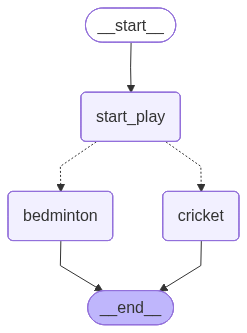

In [4]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

graph=StateGraph(State)

graph.add_node('start_play',start_play)
graph.add_node('cricket',cricket)
graph.add_node('bedminton',bedminton)

##schedule the flow of graph
graph.add_edge(START,'start_play')
graph.add_conditional_edges('start_play',random_play)
graph.add_edge('cricket',END)
graph.add_edge('bedminton',END)


#compile the graph
graph_builder=graph.compile()


#view
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [5]:
graph_builder.invoke({"graph_info":'My name is Kajal'})

start play node called
bedminton node has been called


{'graph_info': 'My name is Kajali am planning to playbedminton planned'}